# Run the full pipeline

This notebook runs the same steps as the command line, using the project code in `src/taxi_duration`:

1. Check that MLflow is running
2. Train and register the baseline model
3. Tune with `GridSearchCV` and compare with the baseline
4. Reload the FastAPI container so it serves the latest model
5. Send prediction requests

**Before you start:** Docker Desktop must be running, with the stack started:
```
docker compose -f docker/compose.yaml up -d
```
Then choose **Run → Run All Cells**. Training takes under a minute, tuning a few minutes.

## 0. Setup

In [1]:
import json
import os
import subprocess
import time
import urllib.request
from pathlib import Path

# Run from the project root so data/, artifacts/ and docker/ resolve correctly
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

import pandas as pd
import matplotlib.pyplot as plt

from taxi_duration import train, tune
from taxi_duration.config import MLFLOW_TRACKING_URI

API_URL = "http://127.0.0.1:8000"
COMPOSE = ["docker", "compose", "-f", "docker/compose.yaml"]

print("Project folder: ", Path.cwd())
print("MLflow:         ", MLFLOW_TRACKING_URI)
print("API:            ", API_URL)

Project folder:  c:\Users\user\Desktop\neuefishe\nf-mle-model-deployment-project
MLflow:          http://127.0.0.1:5001
API:             http://127.0.0.1:8000


## 1. Check that MLflow is running

In [2]:
def is_up(url):
    try:
        urllib.request.urlopen(url, timeout=5)
        return True
    except Exception:
        return False

if is_up(f"{MLFLOW_TRACKING_URI}/health"):
    print(f"MLflow is running. Open {MLFLOW_TRACKING_URI} to watch the runs appear.")
else:
    raise RuntimeError(
        "MLflow is not reachable. Start the stack first:\n"
        "    docker compose -f docker/compose.yaml up -d\n"
        "and wait until `docker compose -f docker/compose.yaml ps` shows mlflow as healthy."
    )

MLflow is running. Open http://127.0.0.1:5001 to watch the runs appear.


## 2. Train and register the baseline model
Same as `uv run python -m taxi_duration.train`. Registers a new version of `random-forest-regressor`.

In [3]:
start = time.perf_counter()
train.main()
print(f"\nTotal time: {time.perf_counter() - start:.0f} s")

Training on 160,000 rows, validating on 40,000 rows


c:\Users\user\Desktop\neuefishe\nf-mle-model-deployment-project\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/10/01 11:07:11 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\user\Desktop\neuefishe\nf-mle-model-deployment-project
2026/10/01 11:07:21 INFO mlflow

🏃 View run baseline at: http://127.0.0.1:5001/#/experiments/1/runs/efd755180b04410bb188b1031d31c73d
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1
RMSE: 4.75 min | MAE: 3.26 min | predict-the-mean RMSE: 9.78 min | train time: 18.4s
Done. Run efd755180b04410bb188b1031d31c73d at http://127.0.0.1:5001

Total time: 63 s


In [4]:
baseline = json.loads(Path("artifacts/metrics.json").read_text())
pd.Series({
    "Validation RMSE (min)": round(baseline["rmse"], 3),
    "Validation MAE (min)": round(baseline.get("mae", float("nan")), 3),
    "Predict-the-mean RMSE (min)": round(baseline["mean_baseline_rmse"], 3),
    "Train time (s)": round(baseline["train_seconds"], 1),
    "Model size (MB)": round(baseline["model_size_mb"], 1),
}, name="Baseline").to_frame()

,Baseline
Validation RMSE (min),4.748
Validation MAE (min),3.255
Predict-the-mean RMSE (min),9.776
Train time (s),18.400
Model size (MB),88.300


## 3. Tune and compare (stretch task)
Same as `uv run python -m taxi_duration.tune`: 18 settings × 3 folds = 54 fits. Takes a few minutes.

The tuned model is only registered if it improves RMSE by at least 1%.

In [5]:
start = time.perf_counter()
tune.main()
print(f"\nTotal time: {time.perf_counter() - start:.0f} s")

Training baseline for comparison ...
Grid search on 50,000 rows ...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best params: {'max_depth': 20, 'max_features': 0.67, 'min_samples_leaf': 20}


c:\Users\user\Desktop\neuefishe\nf-mle-model-deployment-project\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/10/01 11:14:00 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\user\Desktop\neuefishe\nf-mle-model-deployment-project
2026/10/01 11:14:05 INFO mlflow

🏃 View run grid-search at: http://127.0.0.1:5001/#/experiments/1/runs/ef5fbd6c14034e6c9dfa49ddc40f54eb
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1

=== Baseline vs. tuned (validation set) ===
                RMSE     MAE   train s   size MB
baseline        4.75    3.26      17.3      88.3
tuned           4.75    3.25      15.9      51.9
Grid search took 196s; RMSE improvement: 0.03%
Improvement < 1.0%: kept the baseline as the served model.

Total time: 252 s


In [6]:
comp = json.loads(Path("artifacts/comparison.json").read_text())

table = pd.DataFrame({
    name: {
        "RMSE (min)": round(comp[name]["rmse"], 3),
        "MAE (min)": round(comp[name]["mae"], 3),
        "Train time (s)": round(comp[name]["train_seconds"], 1),
        "Size (MB)": round(comp[name]["model_size_mb"], 1),
    }
    for name in ("baseline", "tuned")
}).T
table.loc["predict the mean"] = [round(comp["mean_baseline_rmse"], 3), None, None, None]

print(f"Best grid-search params: { {k: v for k, v in comp['tuned']['params'].items() if k in tune.PARAM_GRID} }")
print(f"Grid search time:        {comp['tuned']['search_seconds']:.0f} s")
print(f"RMSE improvement:        {comp['rmse_improvement_pct']:.2f} %")
print(f"Tuned model registered:  {comp['registered_tuned_model']}")
table

Best grid-search params: {'max_depth': 20, 'min_samples_leaf': 20, 'max_features': 0.67}
Grid search time:        196 s
RMSE improvement:        0.03 %
Tuned model registered:  False


,RMSE (min),MAE (min),Train time (s),Size (MB)
baseline,4.748,3.255,17.3,88.3
tuned,4.746,3.252,15.9,51.9
predict the mean,9.776,NaN,NaN,NaN


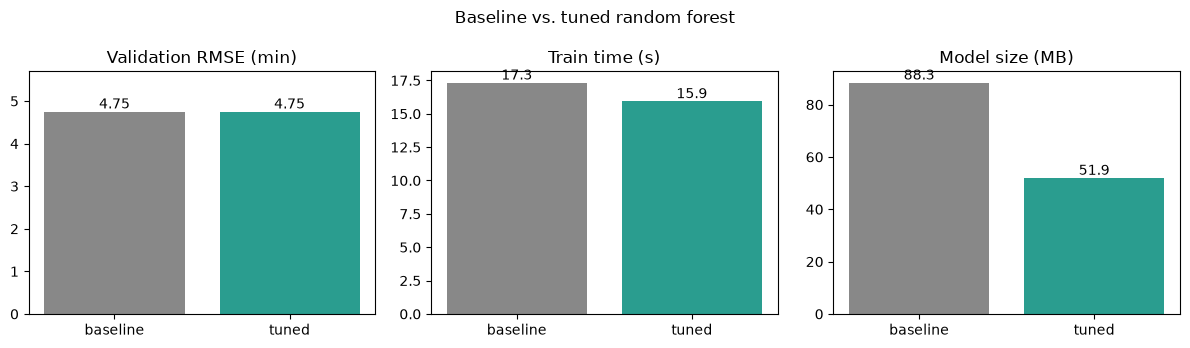

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
names = ["baseline", "tuned"]
for ax, (key, label) in zip(axes, [("rmse", "Validation RMSE (min)"),
                                   ("train_seconds", "Train time (s)"),
                                   ("model_size_mb", "Model size (MB)")]):
    values = [comp[n][key] for n in names]
    ax.bar(names, values, color=["#888", "#2a9d8f"])
    ax.set_title(label)
    for i, v in enumerate(values):
        ax.text(i, v, f"{v:.2f}" if key == "rmse" else f"{v:.1f}", ha="center", va="bottom")
axes[0].set_ylim(0, max(comp["baseline"]["rmse"], comp["tuned"]["rmse"]) * 1.2)
plt.suptitle("Baseline vs. tuned random forest")
plt.tight_layout();

In [8]:
# All grid-search settings, best first
pd.read_csv("artifacts/grid_search_results.csv").head(10)

,params,std_test_score,rank_test_score,mean_cv_rmse
0,"{'max_depth': 20, 'max_features': 0.67, 'min_s...",0.008316,1,4.880882
1,"{'max_depth': 15, 'max_features': 0.67, 'min_s...",0.008708,2,4.881731
2,"{'max_depth': 15, 'max_features': 0.67, 'min_s...",0.005980,3,4.883827
3,"{'max_depth': 10, 'max_features': 0.67, 'min_s...",0.003951,4,4.889245
4,"{'max_depth': 10, 'max_features': 0.67, 'min_s...",0.002547,5,4.893930
5,"{'max_depth': 10, 'max_features': 0.67, 'min_s...",0.006626,6,4.896703
6,"{'max_depth': 20, 'max_features': 0.67, 'min_s...",0.008144,7,4.897786
7,"{'max_depth': 20, 'max_features': 1.0, 'min_sa...",0.015537,8,4.901225
8,"{'max_depth': 15, 'max_features': 1.0, 'min_sa...",0.015556,9,4.901305
9,"{'max_depth': 10, 'max_features': 1.0, 'min_sa...",0.012561,10,4.911128


## 4. Reload the API so it serves the latest model
The API loads the model once at startup, so it must be restarted after training.

In [9]:
subprocess.run(COMPOSE + ["restart", "api"], check=True)

print("Waiting for the API to come back", end="")
for _ in range(60):
    try:
        health = json.load(urllib.request.urlopen(f"{API_URL}/health", timeout=3))
        if health["status"] == "ok":
            break
    except Exception:
        pass
    print(".", end="", flush=True)
    time.sleep(2)
print()
health

Waiting for the API to come back..............


{'status': 'ok',
 'model_uri': 'models:/random-forest-regressor/latest',
 'error': None}

## 5. Send prediction requests

In [10]:
def predict(pu, do, distance):
    body = json.dumps({"PULocationID": pu, "DOLocationID": do, "trip_distance": distance}).encode()
    req = urllib.request.Request(f"{API_URL}/predict", data=body,
                                 headers={"Content-Type": "application/json"}, method="POST")
    with urllib.request.urlopen(req) as resp:
        return json.load(resp)

predict(161, 236, 2.5)   # Midtown Center -> Upper East Side North

{'duration_minutes': 16.17,
 'model_uri': 'models:/random-forest-regressor/latest'}

In [11]:
# A few more trips: short, medium, long, and an airport run
trips = [
    (161, 236, 2.5),   # Midtown -> Upper East Side
    (237, 236, 0.8),   # short hop on the Upper East Side
    (79, 230, 3.0),    # East Village -> Times Square
    (132, 161, 17.0),  # JFK Airport -> Midtown
]
pd.DataFrame(
    [{"pickup": pu, "dropoff": do, "miles": d, "predicted_minutes": predict(pu, do, d)["duration_minutes"]}
     for pu, do, d in trips]
)

,pickup,dropoff,miles,predicted_minutes
0,161,236,2.5,16.17
1,237,236,0.8,6.27
2,79,230,3.0,15.76
3,132,161,17.0,39.29


In [12]:
# Invalid input is rejected with HTTP 422
try:
    predict(999, 236, 2.5)
except urllib.error.HTTPError as e:
    print(f"HTTP {e.code}:", json.load(e)["detail"][0]["msg"])

HTTP 422: Input should be less than or equal to 265


## Done

- Runs and the model registry: **http://127.0.0.1:5001**
- API docs: **http://127.0.0.1:8000/docs**
- Results: `artifacts/metrics.json`, `artifacts/comparison.json`

Each time you run this notebook, training registers a **new model version**, so the version numbers in MLflow will go up. That's expected.